In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import os
from sklearn.impute import SimpleImputer, KNNImputer

## Suprimir advertencias
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
url = 'https://raw.githubusercontent.com/learnradiomics/data_wrangling/main/data_radiomics.xlsx'


data = pd.read_excel(url)
data.shape

(161, 125)

In [ ]:
data.head(3)

### Búsqueda de valores nulos

In [ ]:
data.isnull().sum()

In [ ]:
data = data.drop(columns=['Date of Death','Time to Death (days)', 'Date of Last Known Alive'])
data.head(5)

In [ ]:
### Clinic-pathological data

cp_features = ['Patient affiliation', 'Gender', 'Ethnicity', 'Smoking status', 'Histology',
       'Pathological T stage', 'Histopathological Grade',
       'Lymphovascular invasion', 'EGFR mutation status',
       'KRAS mutation status', 'ALK translocation status', 'Survival Status']

for var in cp_features:
    print(f"Variable: {var}, valores únicos: {data[var].unique()}")
    print(" ")

In [ ]:
##
var_to_review = ['Weight (lbs)', 'Ethnicity', 'Pathological T stage','Histopathological Grade','Lymphovascular invasion',
                'EGFR mutation status', 'KRAS mutation status', 'ALK translocation status' ]


print(f"Variables no registradas (null) en {var_to_review[0]}: {np.where(data[var_to_review[0]] == 'Not Collected')[0].shape[0]}")
print(f"Variables no registradas (null) en {var_to_review[1]}: {np.where(data[var_to_review[1]] == 'Not Recorded In Database')[0].shape[0]}")
print(f"Variables no registradas (null) en {var_to_review[2]}: {np.where(data[var_to_review[2]] == 'Not Collected')[0].shape[0]}")
print(f"Variables no registradas (null) en {var_to_review[3]}: {np.where(data[var_to_review[3]] == 'Not Collected')[0].shape[0]}")
print(f"Variables no registradas (null) en {var_to_review[4]}: {np.where(data[var_to_review[4]] == 'Not Collected')[0].shape[0]}")
print(f"Variables no registradas (null) en {var_to_review[5]}: {np.where(data[var_to_review[5]] == 'Not Collected')[0].shape[0]}")
print(f"Variables no registradas (null) en {var_to_review[6]}: {np.where((data[var_to_review[6]] == 'Not collected') | (data[var_to_review[6]] == 'Unknown') )[0].shape[0]}")
print(f"Variables no registradas (null) en {var_to_review[7]}: {np.where((data[var_to_review[7]] == 'Not collected') | (data[var_to_review[6]] == 'Unknown') )[0].shape[0]}")



### Imputación de valores

In [ ]:
### variables categóricas
df_categoricas = data.loc[:,['Patient affiliation','Gender', 'Ethnicity', 'Smoking status', 'Histology',
       'Pathological T stage', 'Histopathological Grade',
       'Lymphovascular invasion', 'EGFR mutation status',
       'KRAS mutation status', 'ALK translocation status', 'Survival Status']]
df_categoricas.head(3)

In [ ]:
## Separo las variables clinicas numéricas.

var_numericas = ['Age at Histological Diagnosis','Weight (lbs)' ]

df_numericas = data.loc[:,var_numericas]
df_numericas.head(3)

In [ ]:
### radiomics features

df_radiomics_features = data.iloc[:,15:].copy()
df_radiomics_features.head(3)

In [ ]:
### Imputación de Weight (lbs) por la mediana

df_numericas['Weight (lbs)'] = df_numericas['Weight (lbs)'].replace("Not Collected", np.nan)

imputer_median = SimpleImputer(strategy="median")
df_numericas[['Weight (lbs)']] = imputer_median.fit_transform(df_numericas[['Weight (lbs)']])
df_numericas.head(5)

In [ ]:
### Se imputan por la moda algunas de las variables categóricas.
### Hay variables que potencialmente podrían ser usadas como target (ALK y KRAS), no se imputan.

categorical_var = ['Ethnicity', 'Pathological T stage','Histopathological Grade','Lymphovascular invasion',
                'EGFR mutation status', 'KRAS mutation status', 'ALK translocation status']

df_categoricas['Ethnicity']  = df_categoricas['Ethnicity'].replace('Not Recorded In Database', np.nan)
df_categoricas['Pathological T stage']  = df_categoricas['Pathological T stage'].replace('Not Collected', np.nan)
df_categoricas['Histopathological Grade']  = df_categoricas['Histopathological Grade'].replace('Not Collected', np.nan)
df_categoricas['Lymphovascular invasion']  = df_categoricas['Lymphovascular invasion'].replace('Not Collected', np.nan)
#df_categoricas['KRAS mutation status']  = df_categoricas['KRAS mutation status'].replace('Not collected', np.nan)
#df_categoricas['ALK translocation status']  = df_categoricas['ALK translocation status'].replace('Not collected', np.nan)


### Imputar por la moda
cat_imputer = SimpleImputer(strategy="most_frequent")
df_categoricas[categorical_var] = cat_imputer.fit_transform(df_categoricas[categorical_var])
df_categoricas.head(5)

In [ ]:
### Imputación por KNN

df_numericas = data.loc[:,var_numericas]
df_numericas['Weight (lbs)'] = df_numericas['Weight (lbs)'].replace("Not Collected", np.nan)

## Se imputa por K vecinos = 5
imputer_knn = KNNImputer(n_neighbors=5)
knn_matrix = imputer_knn.fit_transform(df_numericas)
df_numericas_knn = pd.DataFrame(knn_matrix, columns=df_numericas.columns)
df_numericas_knn.head(10)

## Codificación de variables categóricas binarias

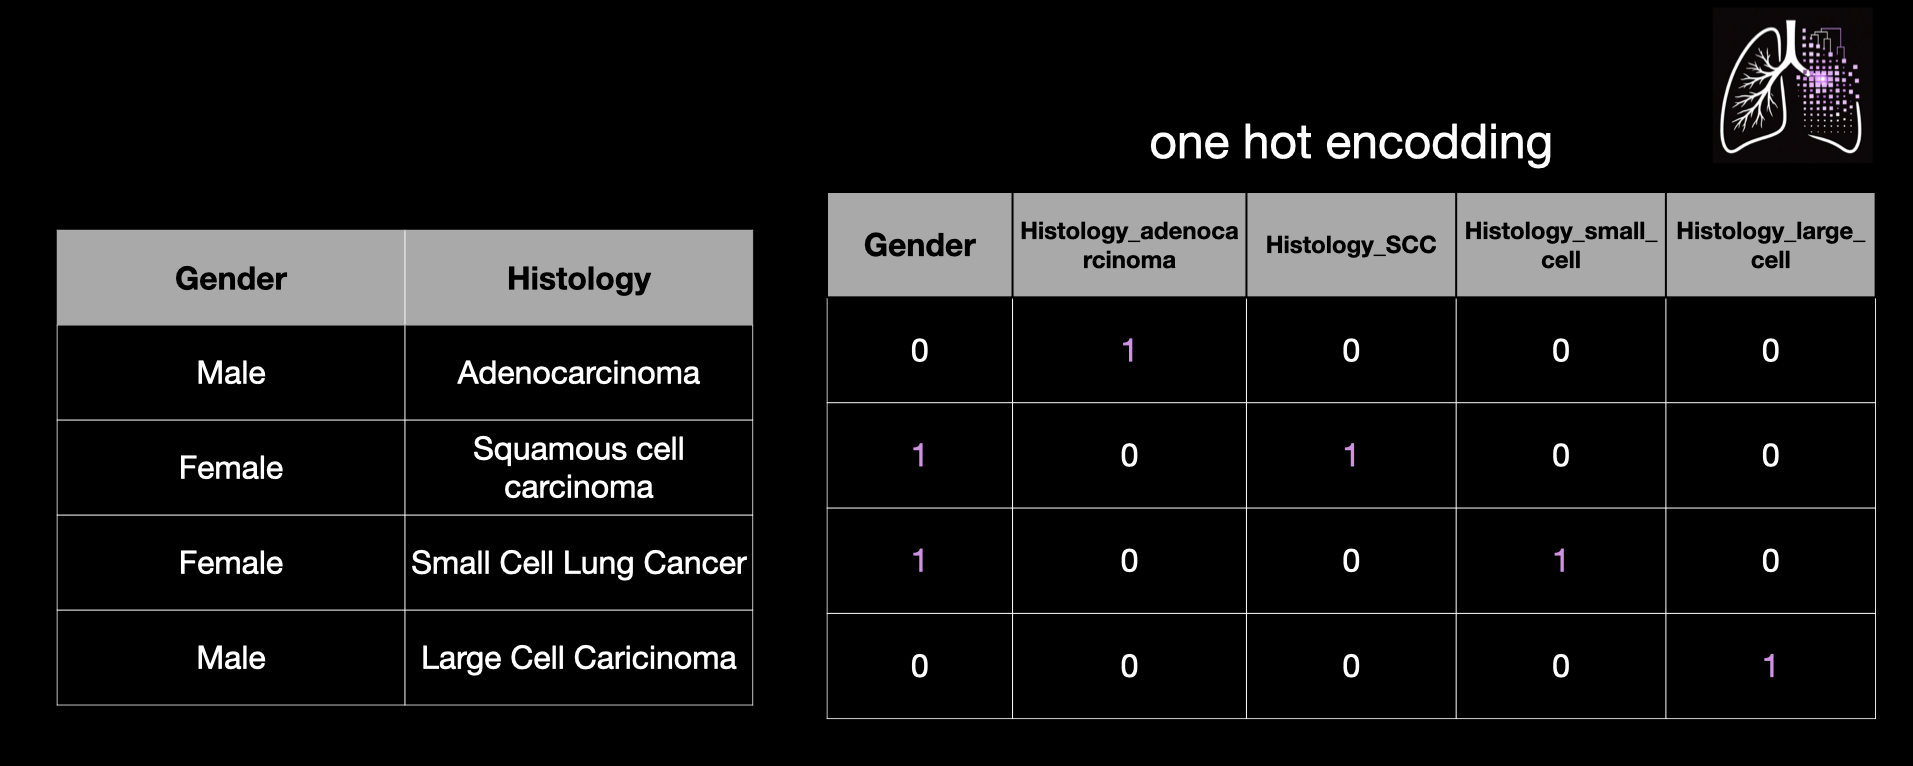

In [ ]:
data.head(3)

In [ ]:
data.Histology.unique()

In [ ]:
### Binarización de variable Gender

data['Gender'].unique()

gender_bin = np.where(data['Gender'] == 'Female', 1.0, 0.0)
gender_bin[0:20]

### Encodding de las variables categóricas

In [ ]:
def categoricalEncoder(dataframe):

    df_categories = pd.DataFrame()
    features_names = []

    for i in range(len(dataframe.columns)):
        instances = dataframe.loc[:,dataframe.columns[i]].unique()

        for j in range(len(instances)):
            new_name = '{}_{}'.format(dataframe.columns[i], instances[j] )
            df_categories[new_name] = np.where(dataframe.iloc[:,i] == instances[j],1.0,0.0)
            features_names.append(new_name)

    df_categories.columns = features_names
    return(df_categories)

In [ ]:
df_cat_encod = categoricalEncoder(df_categoricas)
df_cat_encod.columns

In [ ]:
df_cat_encod.head(3)

In [ ]:
df_cat_encod = df_cat_encod.drop(columns=['Patient affiliation_VA', 'Gender_Male','Smoking status_Former', 'Smoking status_Current'] )

In [ ]:
df_cat_encod.head()

## Variablas numéricas

In [ ]:
df_numericas['Weight (lbs)'] = df_numericas['Weight (lbs)'].replace("Not Collected", np.nan)

imputer_median = SimpleImputer(strategy="median")
df_numericas[['Weight (lbs)']] = imputer_median.fit_transform(df_numericas[['Weight (lbs)']])

In [ ]:
df_numericas.head(5)

### Radiomics features redundantes

In [ ]:
df_radiomics_features.shape

In [ ]:
threshold = 0.5

quasi_constant_cols = []
summary = []

for col in df_radiomics_features.columns:
    freq = df_radiomics_features[col].value_counts(dropna=False, normalize=True)
    top_value = freq.index[0]
    top_freq = freq.iloc[0]

    if top_freq >= threshold:
        quasi_constant_cols.append(col)

    summary.append({
        "column": col,
        "most_frequent_value": top_value,
        "frequency": top_freq,
        "n_unique": df_radiomics_features[col].nunique(dropna=False)
    })

summary_df = pd.DataFrame(summary).sort_values("frequency", ascending=False)

print("Columnas con valor dominante >=", threshold)
print("Cantidad de variables cuasi constantes:", len(quasi_constant_cols))
print(quasi_constant_cols)

summary_df.head(10)

In [ ]:
summary_df.iloc[25:,:].head(10)

In [ ]:
df_radiomics_selected = df_radiomics_features.loc[:,summary_df.column[25:]]
df_numericas_selected.shape

## Unión de tablas

In [ ]:
df_radiomics_total = df_numericas.join(df_radiomics_selected)
df_radiomics_total.head(10)

In [ ]:
df_radiomics_total = df_cat_encod.join(df_radiomics_total)
df_radiomics_total.head(3)

### Seleccionamos las variables que tienen sentido para el problema: Modelar mutación EGFR
>>* y: EGFR mutation status_Mutant
>>* X: Las que puedan aportar al diagnóstico. Eliminaremos las variables derivadas del estudio histopatológico.

In [ ]:
df_radiomics_selected.columns[0:50]

In [ ]:
## Se eliminan algunas variables:
variables_eliminar = ['Patient affiliation_Stanford',  'Histology_Adenocarcinoma', 'Histology_Squamous cell carcinoma',
       'Histology_NSCLC NOS (not otherwise specified)',
       'Pathological T stage_T2a', 'Pathological T stage_T3',
       'Pathological T stage_T1b', 'Pathological T stage_T1a',
       'Pathological T stage_Tis', 'Pathological T stage_T4',
       'Pathological T stage_T2b',
       'Histopathological Grade_G2 Moderately differentiated',
       'Histopathological Grade_Other, Type I: Well to moderately differentiated',
       'Histopathological Grade_G3 Poorly differentiated',
       'Histopathological Grade_G1 Well differentiated',
       'Histopathological Grade_Other, Type II: Moderately to poorly differentiated',
       'Lymphovascular invasion_Absent', 'Lymphovascular invasion_Present','EGFR mutation status_Wildtype','KRAS mutation status_Wildtype',
       'KRAS mutation status_Not collected', 'KRAS mutation status_Unknown','KRAS mutation status_Mutant',
       'ALK translocation status_Wildtype','ALK translocation status_Not collected','ALK translocation status_Unknown',
       'ALK translocation status_Translocated', 'Survival Status_Dead','Survival Status_Alive' ]

In [ ]:
df_radiomics_total = df_radiomics_total.drop(columns=variables_eliminar)

In [ ]:
df_radiomics_total.shape

In [ ]:
df_radiomics_total.head(3)

In [ ]:
df_radiomics_total.to_excel('data_radiomics_selected.xlsx', index=False)